We want to solve $$ \mathrm{d} Y_t^m = \mu(Y_t^m,t) + \varsigma(Y_t^m,t) \mathrm{d} X_t^{m,-} + \sigma(Y_t^m,t) \mathrm{d} W_t^m$$ where 
- $W$ is a $d$-dimensional Brownian motion, $X$ is 1-dimensional $H$-fBm, possibly correlated with $W$; $Y$ is $n$-dimensional
- The ${}^m$ denotes piecewise-linear approximations and the ${}^-$ means lagged w.r.t. $W$ by one interval
- $\mu$ and $\varsigma$ take values in $\mathbb R^n$, $\sigma$ takes values in $\mathbb R^{n \times d}$

We begin by focusing on the case of $H = 1/2$ and $\mathrm{d}[X,W^k]_t = \rho^k \mathrm{d}t$ for some $\rho^k \in [-1,1]$. The equation then becomes $$ \mathrm{d}Y_t = \Big( \mu(Y_t,t) + \frac{\rho^k}{2}[\sigma_k,\varsigma](Y_t,t) \Big)\mathrm{d}t + \varsigma(Y_t,t) \circ \mathrm{d}X_t^- + \sigma(Y_t,t) \circ \mathrm{d}W_t $$ where $[\sigma_k,\varsigma]$ denotes the Lie bracket $\mathrm{D}\varsigma \sigma_k - \mathrm{D}\sigma_k \varsigma$. Let's take $d = 3$ and $\rho^k = \delta^{1k}$.

In [1]:
# Imports
import jax
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, ControlTerm, Euler, Heun, Midpoint, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree, UnsafeBrownianPath

In [5]:
# Global parameters, create brownian path(s)
t0, t1 = 0, 10
epsilon = 0.05
times = jnp.arange(t0, t1, epsilon)
vbt = VirtualBrownianTree(t0, t1, tol=epsilon, shape=(1,), key=jr.PRNGKey(0))
bm_control = vbt.evaluate

bm_control(1)

# Note that here I am only retaining the method evaluate from VirtualBrownianTree. This is because it's the only one
# being used later on. But on should make sure nothing is being thrown out. From now on a "control" will be a
# a function that returns the increment: (s,t) |-> X_t - X_s.

Array([1.3320228], dtype=float32)

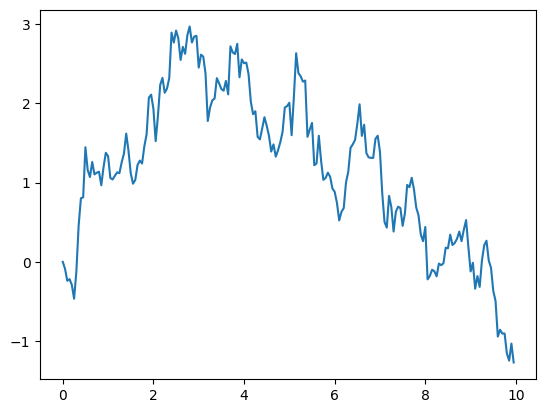

In [6]:
# Transform control (like brownian_motion, or more generally any function) to array, so that it can be plotted
def fun_to_array(grid, fun):
    return jax.vmap(lambda t: fun(t))(grid)
new_times = jnp.arange(1, 2, epsilon)
bm_array = fun_to_array(times, bm_control)
plt.plot(times,bm_array)
plt.show()

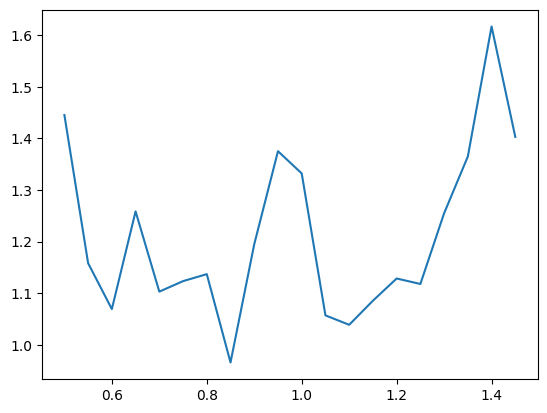

In [87]:
s0, s1 = 10, 30
plt.plot(times[s0:s1],bm_array[s0:s1])
plt.show()

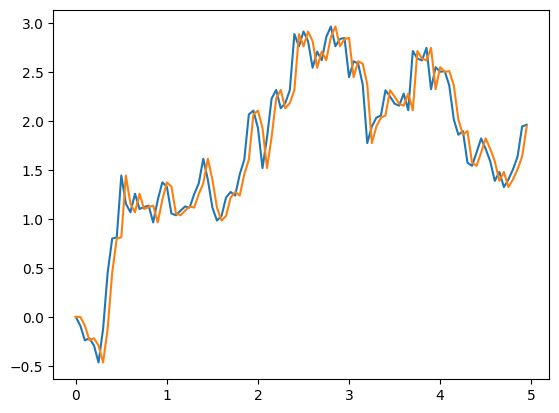

In [7]:
# Create lagged control from a given control and join them
def lagged_control(fun, lag):
    return lambda s,t: fun(jnp.maximum(0,t - lag)) - fun(jnp.maximum(0,s - lag))
lagged_bm_control = lagged_control(bm_control, epsilon)

def join_controls(lagged, original):
    return lambda s,t: jnp.concatenate((lagged(s,t), original(s,t)))

lead_lag_control = join_controls(bm_control, lagged_bm_control)

# Plot them side by side on a small interval
s0, s1 = 0, 100
lead_lag_array = fun_to_array(times, lambda t: lead_lag_control(0,t))
plt.plot(times[s0:s1],lead_lag_array[s0:s1])
plt.show()

In [14]:
# Do a simple example 1-dimensional ODE
# Solver with symbolic coefficients for n-dimensional

Let's start with $X$ and $W$ equal and 1-dimensional. $ \mathrm{d} Y_t^m = \varsigma(Y_t^m) \mathrm{d} X_t^{m,-} + \sigma(Y_t^m) \mathrm{d} W_t^m$ converges to $$ \mathrm{d}Y_t = (\sigma(Y_t) + \varsigma(Y_t)) \circ \mathrm{d}W_t + \frac{1}{2}[\sigma_k,\varsigma](Y_t,t) \mathrm{d}t. $$ Let's compare the solution to the approximating CDE with that to $\mathrm{d}Y_t = (\sigma(Y_t) + \varsigma(Y_t)) \circ \mathrm{d}W_t^m + \frac{1}{2}[\sigma_k,\varsigma](Y_t,t) \mathrm{d}t$.



In [50]:
# First let's compare some of the solvers

diffusion = lambda t, y, args: jnp.array([y])
terms = ControlTerm(diffusion, bm_control)
solverEuler = Euler()
saveat = SaveAt(dense=True)
y0 = 1

# Euler, with finer grid than was used to generate the brownian motion
sol_euler_finer = diffeqsolve(terms, solverEuler, t0, t1, dt0 = epsilon*0.05, y0=y0, saveat=saveat)
euler_finer_array = fun_to_array(times, sol_euler_finer.evaluate)

# Euler, with the same grid as was used to generate the brownian motion
sol_euler_same = diffeqsolve(terms, solverEuler, t0, t1, dt0 = epsilon, y0=y0, saveat=saveat)
euler_same_array = fun_to_array(times, sol_euler_same.evaluate)

solverHeun = Heun()

# Heun, with the finer grid as was used to generate the brownian motion
sol_heun_finer = diffeqsolve(terms, solverHeun, t0, t1, dt0 = epsilon*0.05, y0=y0, saveat=saveat)
heun_finer_array = fun_to_array(times, sol_euler_finer.evaluate)

# Heun, with the same grid as was used to generate the brownian motion
sol_heun_same = diffeqsolve(terms, solverHeun, t0, t1, dt0 = epsilon, y0=y0, saveat=saveat)
heun_same_array = fun_to_array(times, sol_euler_same.evaluate)


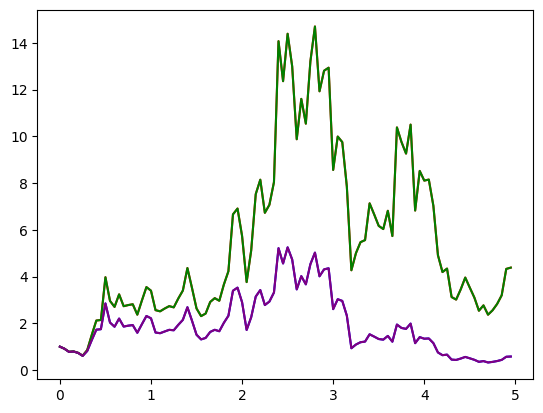

In [51]:
s0, s1 = 0, 100
plt.plot(times[s0:s1], euler_finer_array[s0:s1], color = "red")
plt.plot(times[s0:s1], euler_same_array[s0:s1], color = "blue")
plt.plot(times[s0:s1], heun_finer_array[s0:s1], color = "green")
plt.plot(times[s0:s1], heun_same_array[s0:s1], color = "purple")
plt.show()

# So the solver doesn't matter, but which grid is finer gives you different solutions.

In [145]:
drift = lambda t, y, args: 0
diffusion = lambda t, y, args: y
brownian_motion = VirtualBrownianTree(t0, t1, tol=epsilon, shape=(), key=jr.PRNGKey(101))
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, brownian_motion))
ito_solver = Euler()
strat_solver = Midpoint()
solver_epsilon = 0.001*epsilon
solver_times = jnp.arange(t0, t1, solver_epsilon)
saveat = SaveAt(ts = times)

ito_sol_same = diffeqsolve(terms, ito_solver, t0, t1, dt0 = epsilon, y0=y0, saveat=saveat)
strat_sol_same = diffeqsolve(terms, strat_solver, t0, t1, dt0 = epsilon, y0=y0, saveat=saveat)
#ito_sol_same_array = fun_to_array(times, ito_sol_same.evaluate)
#strat_sol_same_array = fun_to_array(times, strat_sol_same.evaluate)

ito_sol_finer = diffeqsolve(terms, ito_solver, t0, t1, dt0 = solver_epsilon, max_steps = None, y0=y0, saveat=saveat)
strat_sol_finer = diffeqsolve(terms, strat_solver, t0, t1, dt0 = solver_epsilon, max_steps = None, y0=y0, saveat=saveat)
#ito_sol_finer_array = fun_to_array(times, ito_sol_finer.evaluate)
#strat_sol_finer_array = fun_to_array(times, strat_sol_finer.evaluate)

def ito_sol_true(bm):
    return lambda t: jnp.exp(bm(t) - t/2)

def strat_sol_true(bm):
    return lambda t: jnp.exp(bm(t))

ito_true_array = fun_to_array(times, ito_sol_true(brownian_motion.evaluate))
strat_true_array = fun_to_array(times, strat_sol_true(brownian_motion.evaluate))

In [115]:
s0, s1 = 0,20

#plt.plot(times[s0:s1], ito_sol_same_array[s0:s1], color = "cyan")
#plt.plot(times[s0:s1], strat_sol_same_array[s0:s1], color = "orange")

#plt.plot(times[s0:s1], ito_sol_finer_array[s0:s1], color = "blue")
#plt.plot(times[s0:s1], strat_sol_finer_array[s0:s1], color = "red")

#plt.plot(times[s0:s1], ito_true_array[s0:s1], color = "green")
#plt.plot(times[s0:s1], strat_true_array[s0:s1], color = "pink")

plt.show()

'''
So for both Ito and Strat, taking the same grid more or less works (not exactly, but does not
seem ill-conditioned). In the Ito case, the finer grid doesn't work (and also doesn't coincide
with the true Strat solution). In the Stratonovich case, the finer grid works exactly.
The Euler method on a finer grid does not agree with true Strat (which should
happen, because we are just solving an ODE), however it's not far off; Heun or Midpoint are 
needed. It looks like this could be fixed by a much finer grid.
'''

"\nSo for both Ito and Strat, taking the same grid more or less works (not exactly, but does not\nseem ill-conditioned). In the Ito case, the finer grid doesn't work (and also doesn't coincide\nwith the true Strat solution). In the Stratonovich case, the finer grid works exactly.\nThe Euler method on a finer grid does not agree with true Strat (which should\nhappen, because we are just solving an ODE), however it's not far off; Heun or Midpoint are \nneeded. It looks like this could be fixed by a much finer grid.\n"

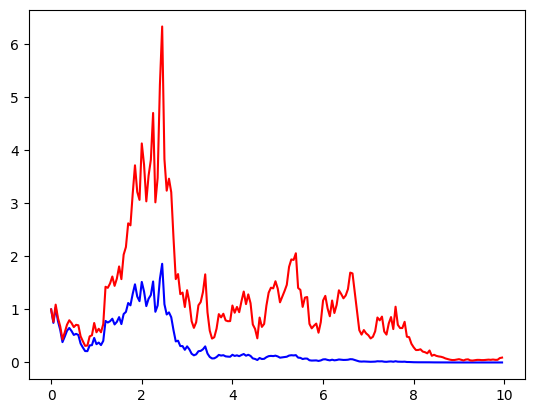

In [147]:
#plt.plot(ito_sol_same.ts, ito_sol_same.ys, color = "cyan")
#plt.plot(strat_sol_same.ts, strat_sol_same.ys, color = "orange")

#plt.plot(ito_sol_finer.ts, ito_sol_finer.ys, color = "cyan")
#plt.plot(strat_sol_finer.ts, strat_sol_finer.ys, color = "orange")

plt.plot(times, ito_true_array, color = "blue")
plt.plot(times, strat_true_array, color = "red")

plt.show()

# In fact, it seems using the finer grid for the solver (Heun or Midpoint) gives the best approx!

Next TODO

- Ito and Strat look very different, path-by-path. Plot several paths in a single plot to assess plausibility.
- Continue using Heun, do lead-lag and compare with Ito.